# PCA on Correlation Matrices
Fit 2D-PCA on the training split, apply it to the test split, and compute reconstruction metrics on the test set only.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder under `data/processed/dataset/`.
The folder must contain `train.pt`, `val.pt`, and `test.pt` with correlation matrices already split.

In [7]:
# Dataset path configuration
DATA_DIR = Path('../data/processed/dataset')
DATASET_NAME = 'corr_windows_tensor_data_00_20_w724_s10_range_49_461_seed42_val20_test10'
DATASET_DIR = DATA_DIR / DATASET_NAME

TRAIN_FILE = DATASET_DIR / 'train.pt'
VAL_FILE = DATASET_DIR / 'val.pt'
TEST_FILE = DATASET_DIR / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(f'File not found: {split_path.resolve()}')

print(f'Dataset folder: {DATASET_DIR.name}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Dataset folder: corr_windows_tensor_data_00_20_w724_s10_range_49_461_seed42_val20_test10
Train: train.pt | Val: val.pt | Test: test.pt


In [8]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_corr_payload(TRAIN_FILE)
val_corr, val_meta = load_corr_payload(VAL_FILE)
test_corr, test_meta = load_corr_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')

print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (289, 362, 362)
val_corr shape:   (82, 362, 362)
test_corr shape:  (41, 362, 362)


## Step 2: Prepare Train/Test Matrices for 2D-PCA
Use each correlation matrix directly as a 2D input (N x N).
Fit PCA on the training split, then apply the same components to the test split.

In [9]:
train_np = train_corr.numpy()
test_np = test_corr.numpy()

n_train, n_assets, _ = train_np.shape
n_test = test_np.shape[0]

print(f'Train matrices: {n_train}')
print(f'Test matrices:  {n_test}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')

Train matrices: 289
Test matrices:  41
Assets per matrix (N): 362
Each input matrix shape: (362, 362)


## Step 3: Fit 2D-PCA on Train, Apply on Test
For every matrix:
- Input shape: N x N
- Reduced representation: N x K
- Reconstructed matrix (via inverse transform): N x N
The PCA components are learned from the training split only.

In [10]:
def fit_2dpca(corr_mats: np.ndarray, n_components: int):
    if corr_mats.ndim != 3 or corr_mats.shape[1] != corr_mats.shape[2]:
        raise ValueError(f'Expected shape (n_samples, N, N), got {corr_mats.shape}')

    n_samples, n_assets, _ = corr_mats.shape
    if not (1 <= n_components <= n_assets):
        raise ValueError(f'n_components must be in [1, {n_assets}]')

    # 1) Mean matrix (train only)
    mean_mat = np.mean(corr_mats, axis=0)

    # 2) Scatter matrix
    diff = corr_mats - mean_mat
    scatter_matrix = np.mean(np.matmul(diff.transpose(0, 2, 1), diff), axis=0)

    # 3) Eigen-decomposition (scatter matrix is symmetric)
    eigenvalues, eigenvectors = np.linalg.eigh(scatter_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # 4) Projection matrix
    projection_matrix = eigenvectors[:, :n_components]

    explained_variance = eigenvalues[:n_components] / np.sum(eigenvalues)

    return {
        'mean_mat': mean_mat,
        'components': projection_matrix,
        'explained_variance': explained_variance
    }


def apply_2dpca(corr_mats: np.ndarray, mean_mat: np.ndarray, projection_matrix: np.ndarray):
    if corr_mats.ndim != 3 or corr_mats.shape[1] != corr_mats.shape[2]:
        raise ValueError(f'Expected shape (n_samples, N, N), got {corr_mats.shape}')

    # Project and reconstruct using train-fitted components
    projected_mats = np.matmul(corr_mats, projection_matrix)
    recon_mats = np.matmul(projected_mats, projection_matrix.T)

    # Keep correlation-matrix structure after reconstruction.
    #recon_mats = 0.5 * (recon_mats + np.transpose(recon_mats, (0, 2, 1)))
    #for i in range(recon_mats.shape[0]):
    #    np.fill_diagonal(recon_mats[i], 1.0)

    return {
        'projected': projected_mats,
        'recon_corr': recon_mats
    }

In [11]:
N_COMPONENTS = 12
if N_COMPONENTS > n_assets:
    raise ValueError(f'N_COMPONENTS={N_COMPONENTS} is too large, max is {n_assets}')

pca_fit = fit_2dpca(train_np, n_components=N_COMPONENTS)
pca_test = apply_2dpca(test_np, pca_fit['mean_mat'], pca_fit['components'])

explained_ratio = pca_fit['explained_variance']
var_percent = explained_ratio.sum() * 100
print('--- 2D-PCA Results (fit on train, applied to test) ---')
print(f'Train tensor shape:          {train_np.shape}')
print(f'Test tensor shape:           {test_np.shape}')
print(f'Reduced test shape (N x K):  {pca_test["projected"].shape}')
print(f'Components extracted (K):    {N_COMPONENTS}')
print(f'Explained variance (top K):  {var_percent:.2f}%\n')
for idx, var in enumerate(explained_ratio):
    print(f'Variance PC{idx+1}: {(var * 100):.2f}%')

--- 2D-PCA Results (fit on train, applied to test) ---
Train tensor shape:          (289, 362, 362)
Test tensor shape:           (41, 362, 362)
Reduced test shape (N x K):  (41, 362, 12)
Components extracted (K):    12
Explained variance (top K):  93.84%

Variance PC1: 75.21%
Variance PC2: 7.23%
Variance PC3: 3.01%
Variance PC4: 1.96%
Variance PC5: 1.60%
Variance PC6: 1.27%
Variance PC7: 1.05%
Variance PC8: 0.80%
Variance PC9: 0.59%
Variance PC10: 0.45%
Variance PC11: 0.39%
Variance PC12: 0.31%


## Step 4: Reconstruct Correlation Matrices
Reconstruct each matrix from its N x K representation using inverse transform.
Then enforce symmetry and set the diagonal to 1.0 to keep correlation-matrix structure.

In [12]:
orig_corr = test_np
recon_corr = pca_test['recon_corr']
reduced_corr = pca_test['projected']

print(f'orig_corr shape: {orig_corr.shape}')
print(f'reduced_corr shape (N x K): {reduced_corr.shape}')
print(f'recon_corr shape: {recon_corr.shape}')

orig_corr shape: (41, 362, 362)
reduced_corr shape (N x K): (41, 362, 12)
recon_corr shape: (41, 362, 362)


## Step 5: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.1917 0.248  0.363  0.3976]
 [0.1917 1.     0.1503 0.3586 0.1955]
 [0.248  0.1503 1.     0.2554 0.2737]
 [0.363  0.3586 0.2554 1.     0.4432]
 [0.3976 0.1955 0.2737 0.4432 1.    ]]
Reconstructed Matrix:
[[0.3734 0.2116 0.2229 0.5052 0.362 ]
 [0.1681 0.3581 0.2049 0.4043 0.2145]
 [0.2495 0.1924 0.2548 0.4274 0.2478]
 [0.4313 0.3742 0.3046 0.7671 0.4379]
 [0.4135 0.2673 0.2823 0.5901 0.4391]]
Error Matrix:
[[-0.6266  0.0199 -0.0251  0.1422 -0.0356]
 [-0.0236 -0.6419  0.0545  0.0456  0.019 ]
 [ 0.0015  0.0421 -0.7452  0.172  -0.0259]
 [ 0.0683  0.0155  0.0493 -0.2329 -0.0053]
 [ 0.0159  0.0718  0.0086  0.1469 -0.5609]]
Sample index: 40
MSE: 0.002925 | MAE: 0.035718 | Frobenius: 19.579302
Error range - Min: -0.847765 | Max: 0.283713


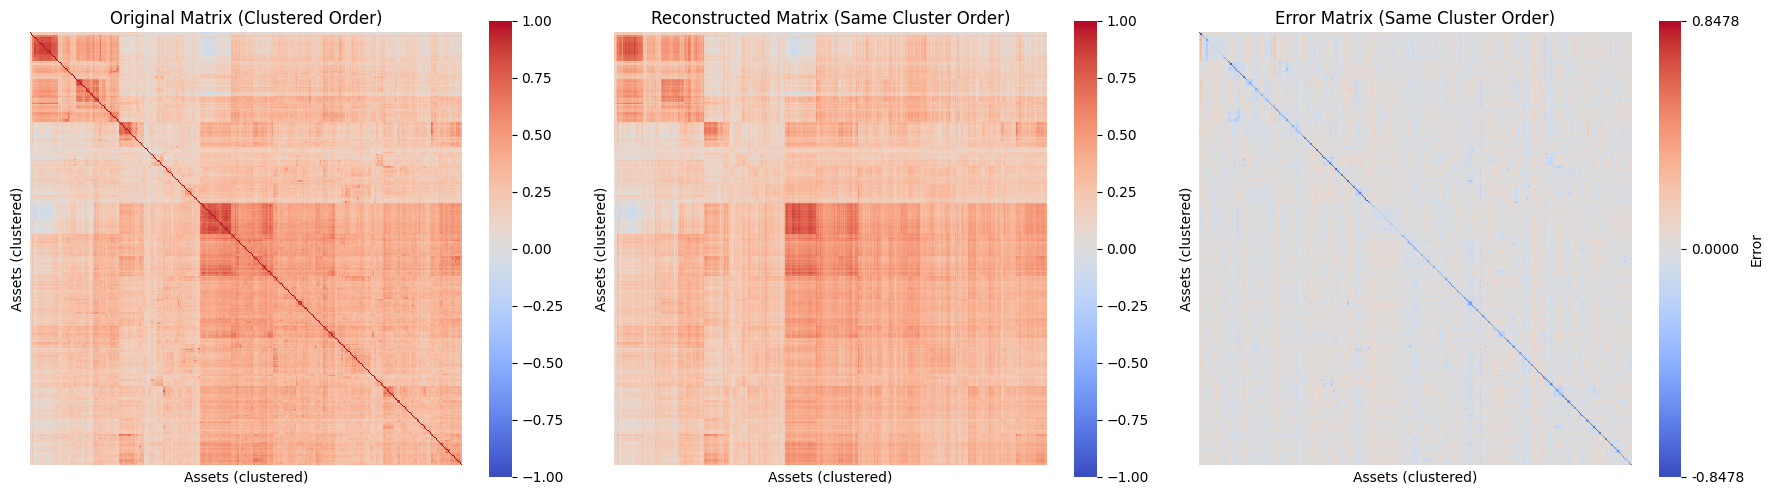

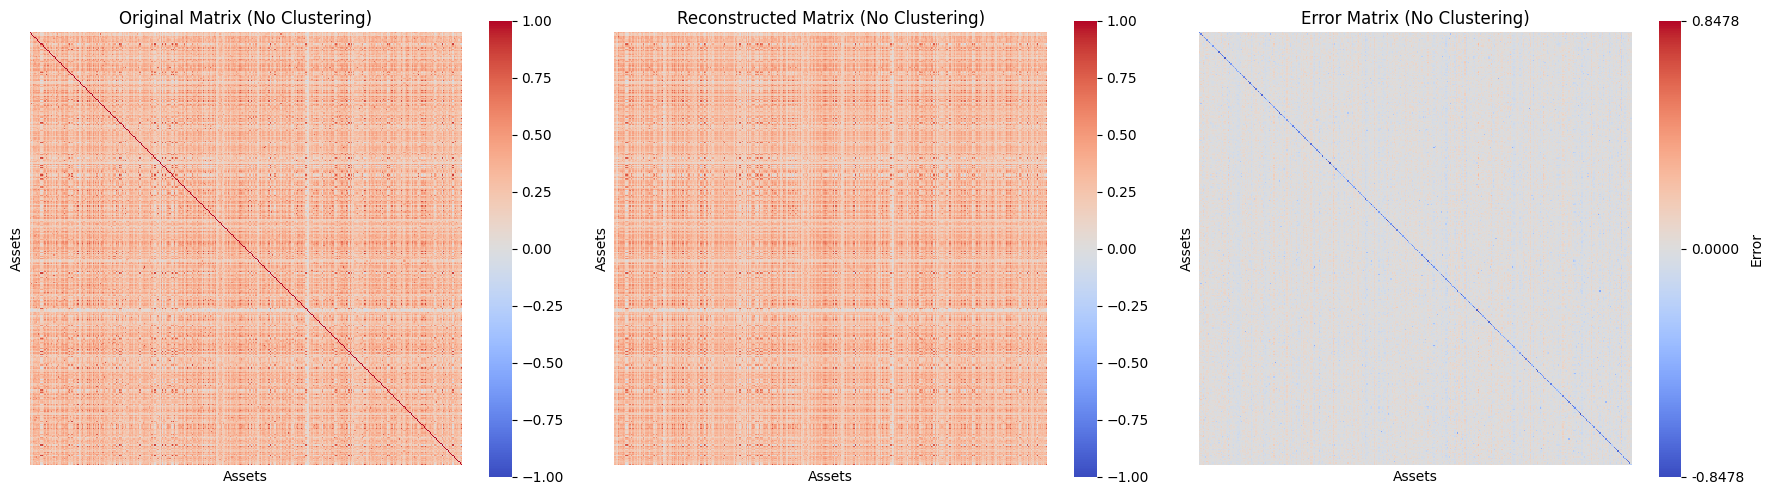

In [18]:
SAMPLE_IDX = 40

if not (0 <= SAMPLE_IDX < orig_corr.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {orig_corr.shape[0] - 1}]')

orig_mat = orig_corr[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

# Use the same colormap for all matrices.
shared_cmap = 'coolwarm'

# Error scale must be symmetric around zero: [-max|err|, +max|err|]
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

# Clustered heatmaps in a single side-by-side figure (without dendrograms).
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(err_mat, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max, cmap=shared_cmap, center=0, square=True, cbar_kws={'label': 'Error'})
axes[2].set_title('Error Matrix (No Clustering)')
# Set colorbar ticks for standard heatmap
cbar = hm.collections[0].colorbar
cbar.set_ticks([-err_abs_max, 0, err_abs_max])
cbar.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 6: Calculate Reconstruction Errors (Test Set)
Measure reconstruction quality on the test split using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [14]:
def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats


errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)

print('Reconstruction error statistics (test set):')
display(errors_stats)

Reconstruction error statistics (test set):


,mean,std,min,median,max
MSE,0.002883,0.000540,0.002039,0.002848,0.003824
MAE,0.036211,0.003100,0.030817,0.036912,0.042757
Frobenius,19.351311,1.834177,16.346470,19.317266,22.386164


## Step 7: Error Analysis Across Components
Sweep over different numbers of PCA components (fit on train, evaluate on test) and track how reconstruction errors change.

In [15]:
# Error evaluation varying number of components (fit on train, evaluate on test)
candidate_components = [1, 2, 3, 5, 10, 12, 20, 30, 40, 50, 100, 200, 362]
candidate_components = [c for c in candidate_components if c <= n_assets]
print(f'Evaluating PCA reconstruction errors for components: {candidate_components}')
rows = []
for n_comp in candidate_components:
    fit_out = fit_2dpca(train_np, n_comp)
    test_out = apply_2dpca(test_np, fit_out['mean_mat'], fit_out['components'])
    recon = test_out['recon_corr']
    _, stats = reconstruction_errors(test_np, recon)

    rows.append({
        'n_components': n_comp,
        'cumulative_explained_variance': float(fit_out['explained_variance'].sum()),
        'MSE_mean': float(stats.loc['MSE', 'mean']),
        'MAE_mean': float(stats.loc['MAE', 'mean']),
        'Frobenius_mean': float(stats.loc['Frobenius', 'mean'])
    })

sweep_df = pd.DataFrame(rows)
display(sweep_df)

Evaluating PCA reconstruction errors for components: [1, 2, 3, 5, 10, 12, 20, 30, 40, 50, 100, 200, 362]


,n_components,cumulative_explained_variance,MSE_mean,MAE_mean,Frobenius_mean
0,1,0.752103,1.250416e-02,8.052586e-02,39.830235
1,2,0.824366,8.126780e-03,6.485837e-02,32.431572
2,3,0.854421,7.404607e-03,6.188143e-02,30.968267
3,5,0.890034,4.819365e-03,4.810815e-02,24.967834
4,10,0.931450,3.452807e-03,4.034347e-02,21.171892
5,12,0.938447,2.882660e-03,3.621079e-02,19.351311
6,20,0.953983,1.931088e-03,2.834234e-02,15.835503
7,30,0.962426,1.454310e-03,2.370547e-02,13.726194
8,40,0.967436,1.252166e-03,2.194287e-02,12.733892
9,50,0.971047,1.117699e-03,2.078521e-02,12.026668


## Step 8: Visualize Results
Generate plots showing:
1. **Cumulative explained variance** from the train fit
2. **Reconstruction errors** (MSE, MAE, Frobenius) computed on the test set

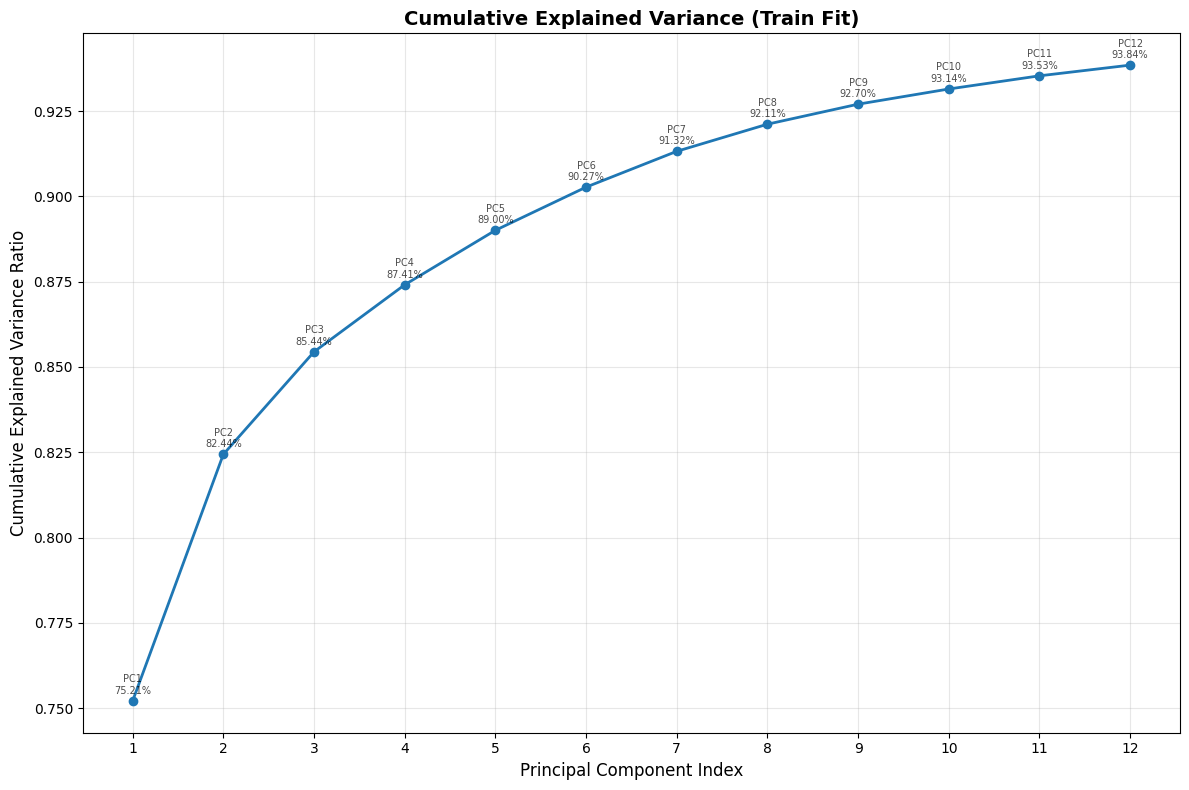

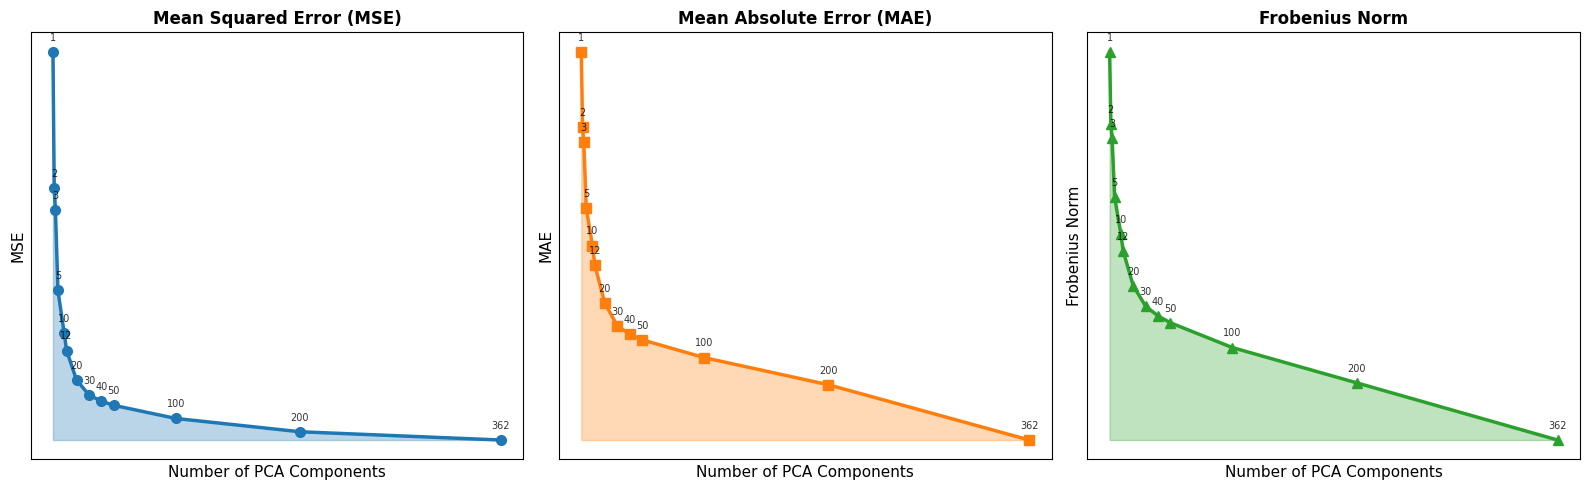

In [16]:
# Plot 1: Cumulative Explained Variance (from train fit)
fig1, ax1 = plt.subplots(figsize=(12, 8))

cum_var = np.cumsum(pca_fit['explained_variance'])
ax1.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for i, val in enumerate(cum_var):
    ax1.annotate(f'PC{i+1}\n{val*100:.2f}%', 
                 xy=(i+1, val), 
                 xytext=(0, 5), 
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title('Cumulative Explained Variance (Train Fit)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component Index', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks((np.arange(1, len(cum_var) + 1)))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Reconstruction Errors on Test Set with separate subplots for each metric
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE subplot
axes[0].plot(sweep_df['n_components'], sweep_df['MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['MSE_mean'], alpha=0.3, color='#1f77b4')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MSE_mean'])):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of PCA Components', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE subplot
axes[1].plot(sweep_df['n_components'], sweep_df['MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['MAE_mean'], alpha=0.3, color='#ff7f0e')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MAE_mean'])):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of PCA Components', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Frobenius norm subplot
axes[2].plot(sweep_df['n_components'], sweep_df['Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Frobenius_mean'], alpha=0.3, color='#2ca02c')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['Frobenius_mean'])):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[2].set_title('Frobenius Norm', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of PCA Components', fontsize=11)
axes[2].set_ylabel('Frobenius Norm', fontsize=11)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()